# QuantAgent-RL — Data Module Demo

This notebook walks through the full `data` module pipeline:
1. Configure the system
2. Ingest market data, macro signals, and SEC filings
3. Engineer GPU-accelerated features
4. Generate walk-forward train/test folds
5. Inspect feature distributions and the state matrix

> **Prerequisites**: Set `FRED_API_KEY` env var before running.

In [1]:
import os
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print('Libraries loaded.')

Libraries loaded.


## 1. Configuration

In [2]:
from data import DataConfig, UniverseConfig, DateRangeConfig, FeatureConfig

cfg = DataConfig(
    universe=UniverseConfig(
        tickers=[
            'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META',
            'AMZN', 'JPM', 'JNJ', 'XOM', 'PG',
            'UNH', 'BAC', 'LLY', 'AVGO', 'CAT',
            'RTX', 'WMT', 'KO', 'NEE', 'PLD',
        ],
        benchmark_ticker='SPY',
        min_history_years=5.0,
    ),
    dates=DateRangeConfig(
        start_date='2010-01-04',
        end_date='2024-12-31',
        rebalance_freq='QE',
    ),
    features=FeatureConfig(
        use_gpu=None,   # auto-detect GPU
    ),
)

print('DataConfig:')
print(f'  Tickers      : {len(cfg.universe.tickers)}')
print(f'  Date range   : {cfg.dates.start_date} → {cfg.dates.end_date}')
print(f'  FRED API key : {"set" if cfg.macro.api_key else "NOT SET — set FRED_API_KEY env var"}')

DataConfig:
  Tickers      : 20
  Date range   : 2010-01-04 → 2024-12-31
  FRED API key : set


## 2. Run the Data Pipeline

In [3]:
from data import DataPipeline

pipeline = DataPipeline(cfg)
pipeline.run(
    skip_sec=False,       # Set False to download SEC filings (slow first run)
    use_cache=True,      # Use cached parquet files if available
    force_refresh=True, # Set True to re-download all data
)

pipeline.summary()

2026-03-29 15:08:27 [INFO] data.pipeline: ============================================================
2026-03-29 15:08:27 [INFO] data.pipeline: QuantAgent-RL Data Pipeline
2026-03-29 15:08:27 [INFO] data.pipeline: ============================================================
2026-03-29 15:08:27 [INFO] data.pipeline: [Pipeline] Stage 1: Market data ingestion
2026-03-29 15:08:27 [INFO] data.ingestion: [MarketData] Downloading batch 1/1: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMZN', 'JPM', 'JNJ', 'XOM', 'PG', 'UNH', 'BAC', 'LLY', 'AVGO', 'CAT', 'RTX', 'WMT', 'KO', 'NEE', 'PLD', 'SPY']
2026-03-29 15:08:28 [INFO] data.pipeline: [Pipeline] Market data: 21 tickers, 3773 trading days (2010-01-04 → 2024-12-30)
2026-03-29 15:08:28 [INFO] data.pipeline: [Pipeline] Stage 2: Macro data ingestion
2026-03-29 15:08:28 [INFO] data.ingestion: [MacroData] Fetching FEDFUNDS → fed_funds_rate
2026-03-29 15:08:29 [INFO] data.ingestion: [MacroData] Fetching CPIAUCSL → cpi_yoy
2026-03-29 15:08:29 [INFO] da

QuantAgent-RL Data Pipeline Summary
Universe          : 19 assets
Date range        : 2010-01-04 → 2024-12-31
Rebalance freq    : QE
Rebalance dates   : 60
Walk-forward folds: 12
Macro signals     : 26
SEC filings       : 222
Feature matrix    : (60, 266)
GPU backend       : None

Sector distribution:
sector
Information Technology    4
Health Care               3
Consumer Staples          3
Financials                2
Industrials               2
Communication Services    1
Consumer Discretionary    1
Energy                    1
Utilities                 1
Real Estate               1

Walk-forward folds:
  WalkForwardFold(fold=0, train=2010-03-31→2012-12-31 (12Q), test=2013-03-31→2013-12-31 (4Q), n_assets=19)
  WalkForwardFold(fold=1, train=2010-03-31→2013-12-31 (16Q), test=2014-03-31→2014-12-31 (4Q), n_assets=19)
  WalkForwardFold(fold=2, train=2010-03-31→2014-12-31 (20Q), test=2015-03-31→2015-12-31 (4Q), n_assets=19)
  WalkForwardFold(fold=3, train=2010-03-31→2015-12-31 (24Q), test=20

## 3. Universe Inspection

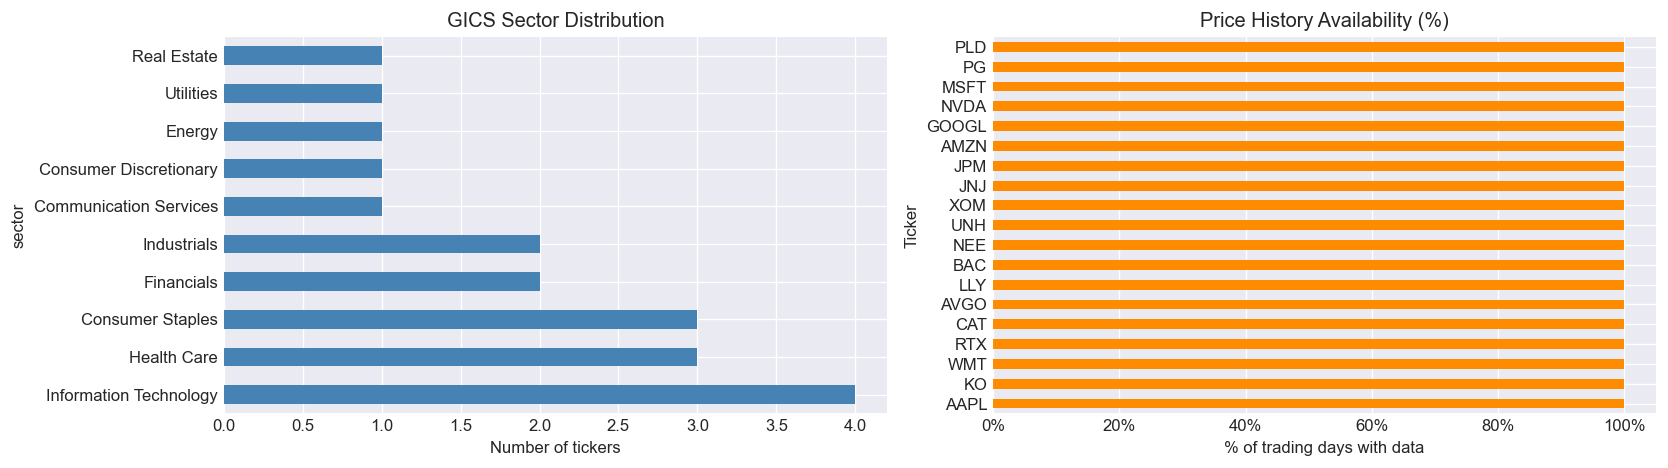

In [4]:
universe = pipeline.universe

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Sector distribution
universe.sector_counts.plot.barh(ax=ax1, color='steelblue')
ax1.set_title('GICS Sector Distribution')
ax1.set_xlabel('Number of tickers')

# Price history availability
availability = pipeline.all_prices.notna().sum() / len(pipeline.all_prices) * 100
availability.sort_values().plot.barh(ax=ax2, color='darkorange')
ax2.set_title('Price History Availability (%)')
ax2.set_xlabel('% of trading days with data')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 4. Market Data

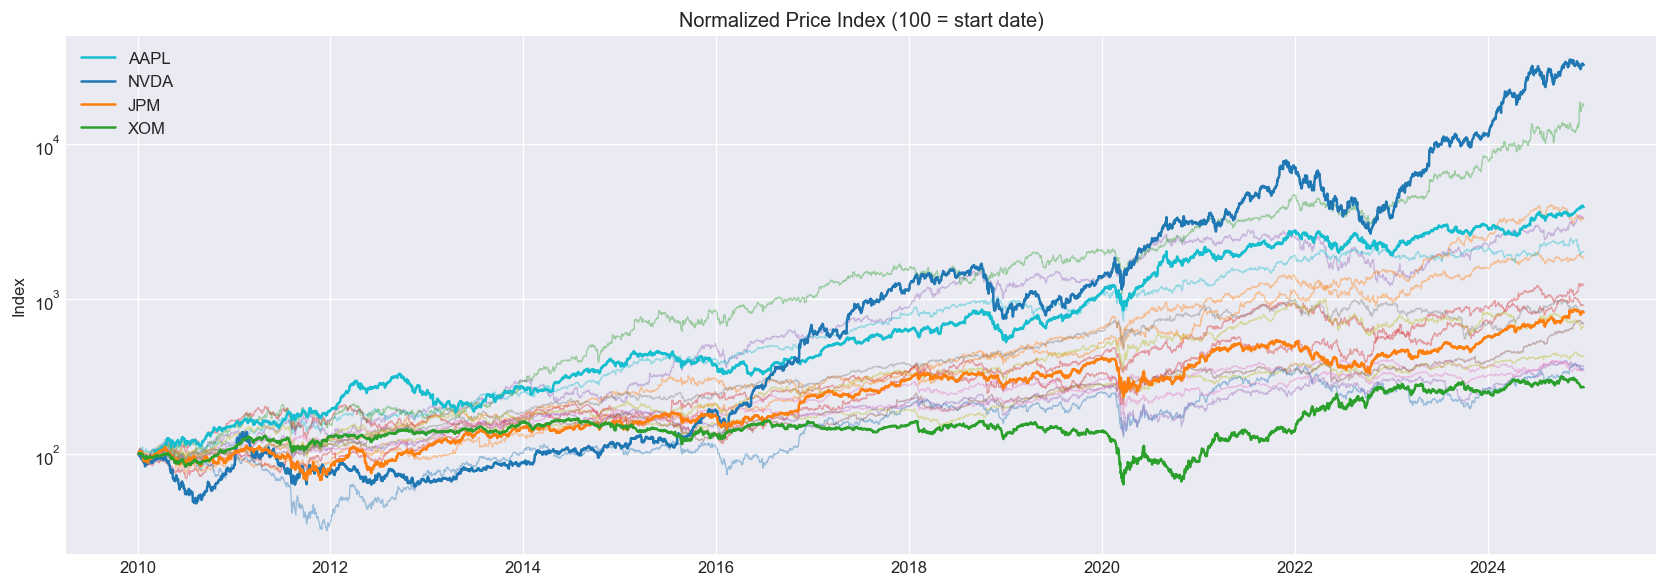

In [5]:
prices = pipeline.all_prices

# Normalized price index (rebased to 100 at start)
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], alpha=0.4, linewidth=0.8)

# Highlight a few key names
for ticker in ['AAPL', 'NVDA', 'JPM', 'XOM']:
    if ticker in normalized.columns:
        ax.plot(normalized.index, normalized[ticker], linewidth=1.5, label=ticker)

ax.set_title('Normalized Price Index (100 = start date)')
ax.set_ylabel('Index')
ax.legend(loc='upper left')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 5. Macro Signals

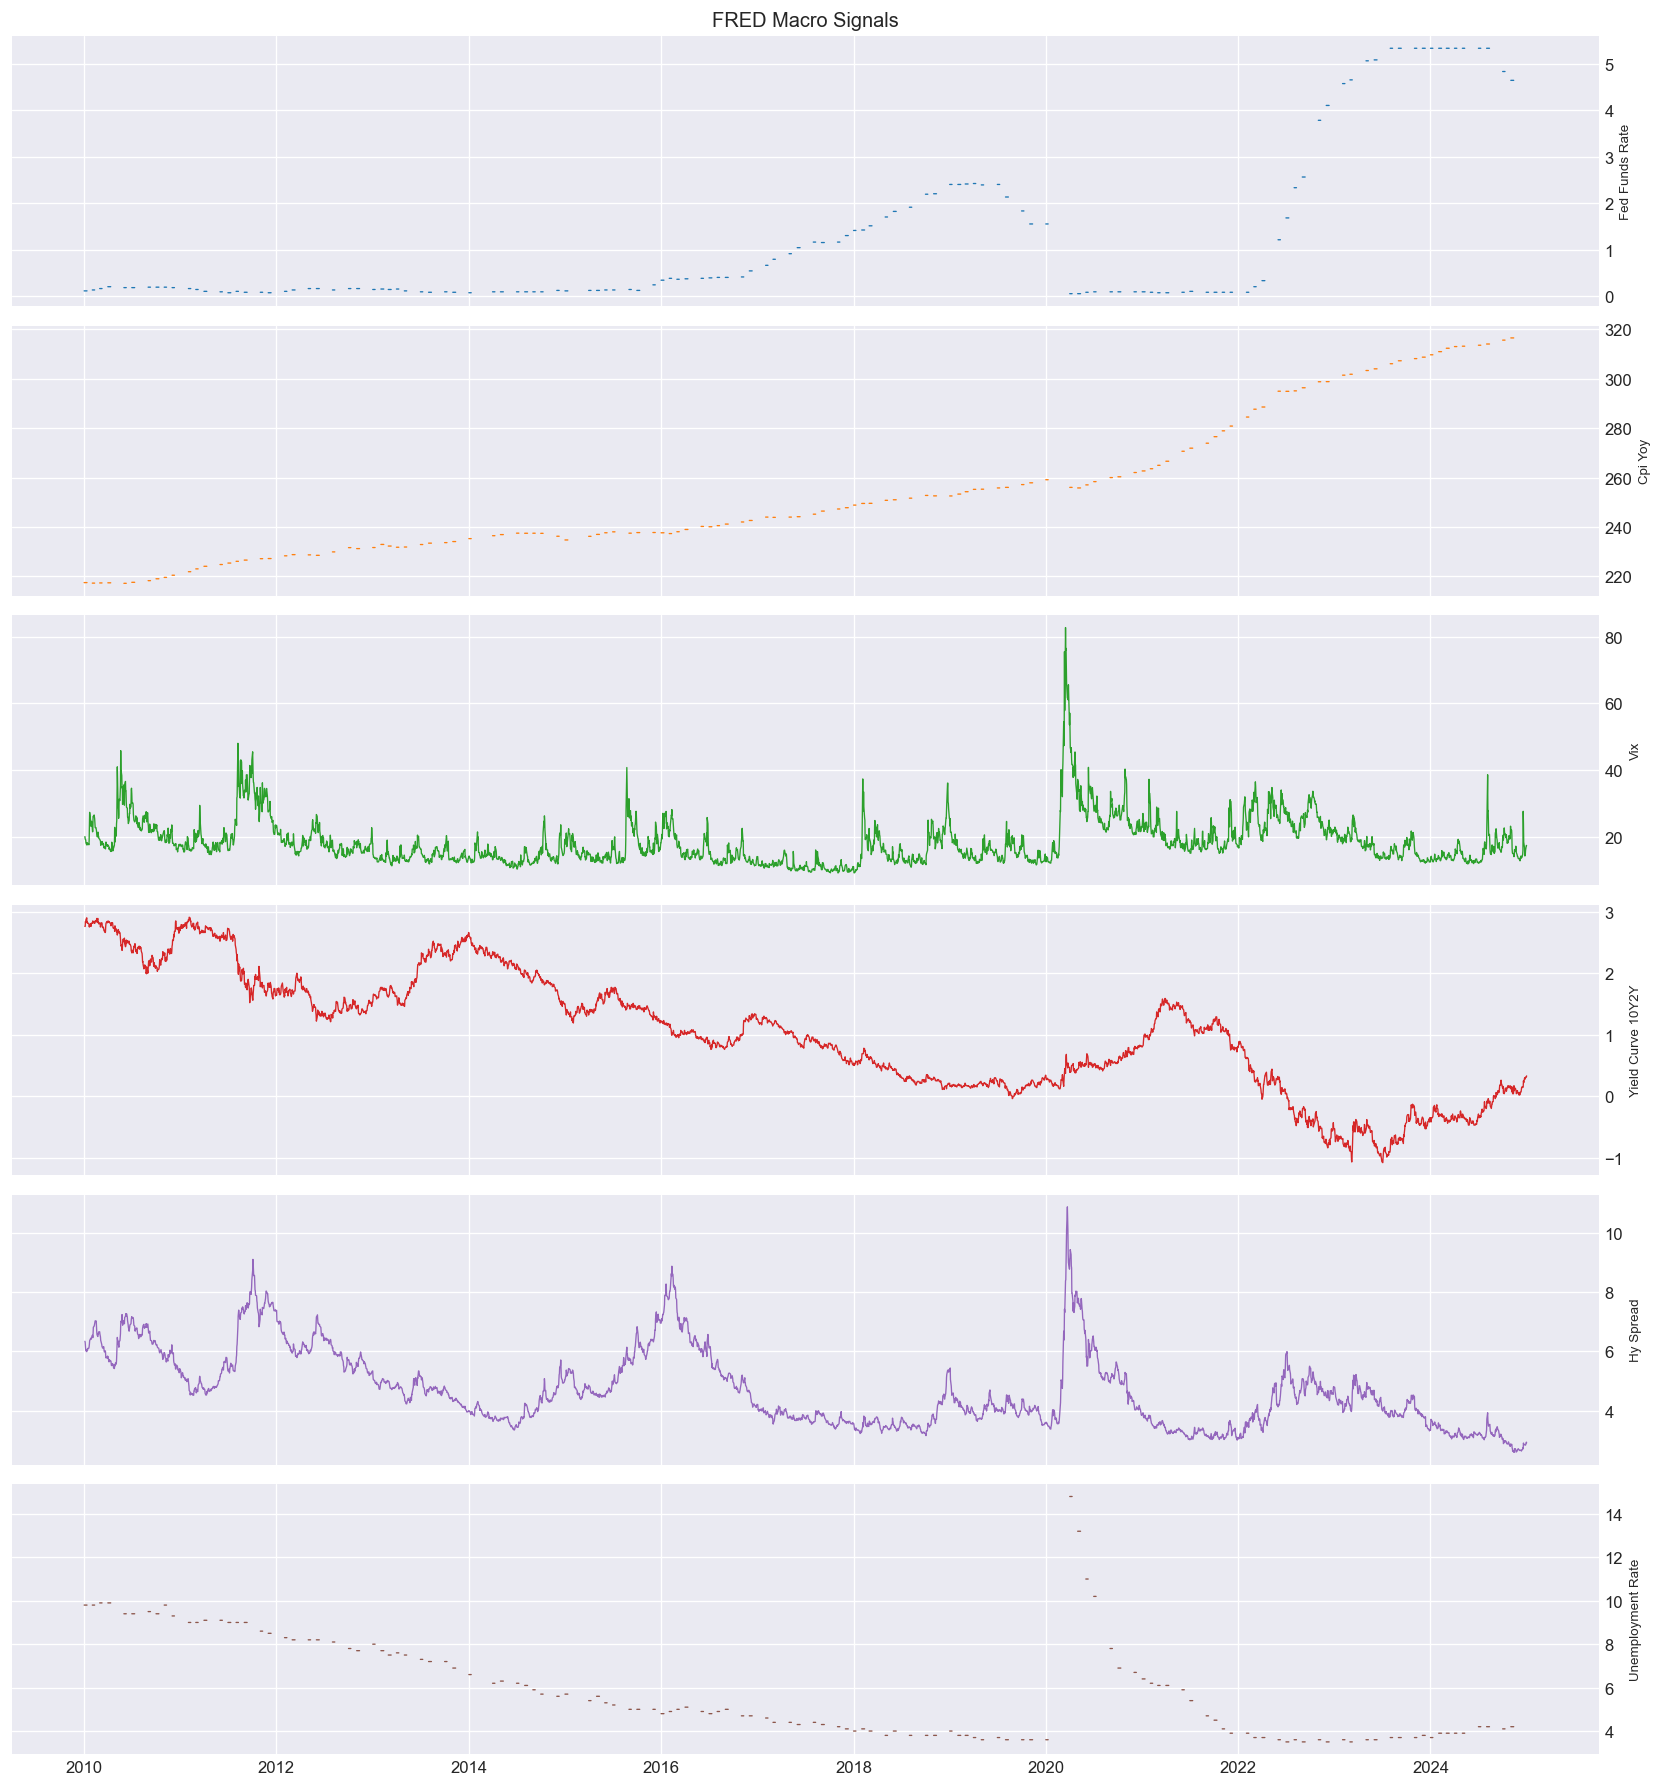

In [6]:
macro = pipeline.macro
base_signals = ['fed_funds_rate', 'cpi_yoy', 'vix', 'yield_curve_10y2y', 'hy_spread', 'unemployment_rate']
available = [s for s in base_signals if s in macro.columns]

fig, axes = plt.subplots(len(available), 1, figsize=(14, 2.5 * len(available)), sharex=True)
colors = plt.cm.tab10.colors

for ax, col, color in zip(axes, available, colors):
    ax.plot(macro.index, macro[col], color=color, linewidth=0.8)
    ax.set_ylabel(col.replace('_', ' ').title(), fontsize=8)
    ax.yaxis.set_label_position('right')
    ax.yaxis.tick_right()

axes[0].set_title('FRED Macro Signals')
plt.tight_layout()
plt.show()

## 6. Feature Matrix

In [7]:
fold = pipeline.get_fold(0)
print(fold)
print()
print('Train state matrix shape:', fold.train_state_matrix.shape)
print('Test state matrix shape: ', fold.test_state_matrix.shape)
print()
print('Feature groups (first level of MultiIndex columns):')
print(fold.train_state_matrix.columns.get_level_values(0).unique().tolist())

WalkForwardFold(fold=0, train=2010-03-31→2012-12-31 (12Q), test=2013-03-31→2013-12-31 (4Q), n_assets=19)

Train state matrix shape: (12, 266)
Test state matrix shape:  (4, 266)

Feature groups (first level of MultiIndex columns):
['ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d', 'mom_21d', 'mom_63d', 'mom_126d', 'rsi', 'bb_position', 'amihud_illiquidity', 'volume_zscore', 'xs_zscore', 'beta_63d']


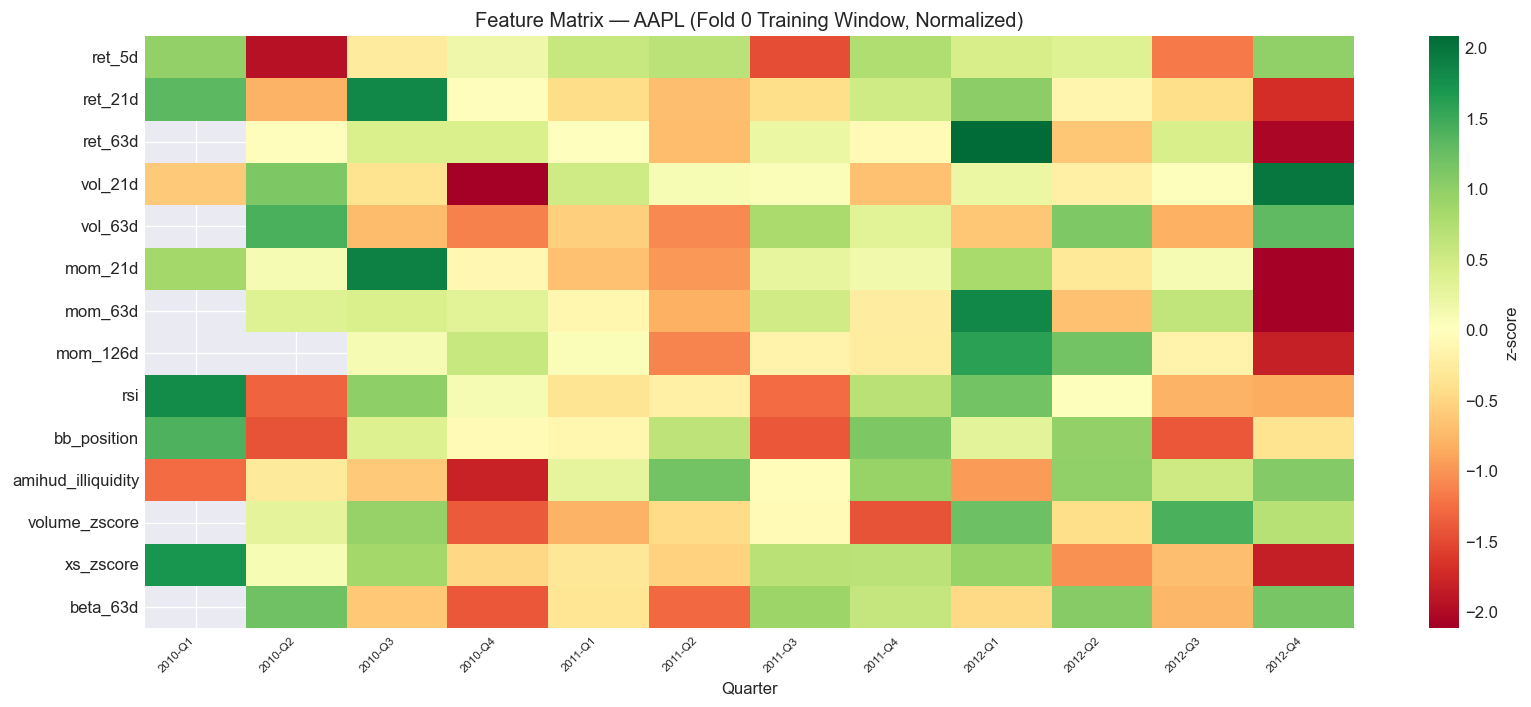

In [8]:
# Feature distribution heatmap (AAPL across all feature groups)
ticker = fold.tickers[0]
ticker_features = fold.train_state_matrix.xs(ticker, level=1, axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    ticker_features.T,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'z-score'},
    xticklabels=[d.to_period("Q").strftime('%Y-Q%q') if hasattr(d, 'strftime') else str(d) for d in ticker_features.index],
    yticklabels=True,
)
ax.set_title(f'Feature Matrix — {ticker} (Fold 0 Training Window, Normalized)')
ax.set_xlabel('Quarter')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 7. Walk-Forward Folds Overview

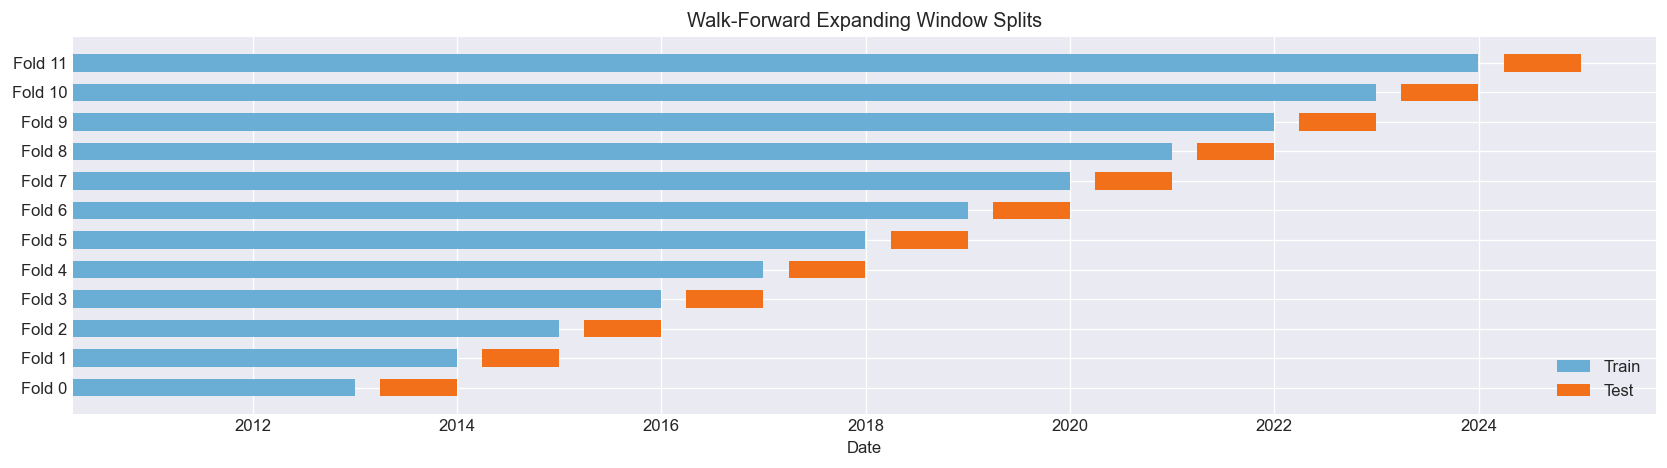


Total folds: 12
Each test window: 4 quarters (1 year)
Training window grows by 4 quarters each fold (expanding)


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

colors_train = plt.cm.Blues(0.5)
colors_test  = plt.cm.Oranges(0.6)

for i in range(pipeline.n_folds):
    f = pipeline.get_fold(i)
    ax.barh(i, (f.train_end - f.train_start).days, left=f.train_start,
            height=0.6, color=colors_train, label='Train' if i == 0 else '')
    ax.barh(i, (f.test_end - f.test_start).days, left=f.test_start,
            height=0.6, color=colors_test, label='Test' if i == 0 else '')

ax.set_yticks(range(pipeline.n_folds))
ax.set_yticklabels([f'Fold {i}' for i in range(pipeline.n_folds)])
ax.set_xlabel('Date')
ax.set_title('Walk-Forward Expanding Window Splits')
ax.legend(loc='lower right')
ax.xaxis_date()
plt.tight_layout()
plt.show()

print(f'\nTotal folds: {pipeline.n_folds}')
print(f'Each test window: 4 quarters (1 year)')
print(f'Training window grows by 4 quarters each fold (expanding)')

## 8. Total Return Index (Dividend-Reinvested)

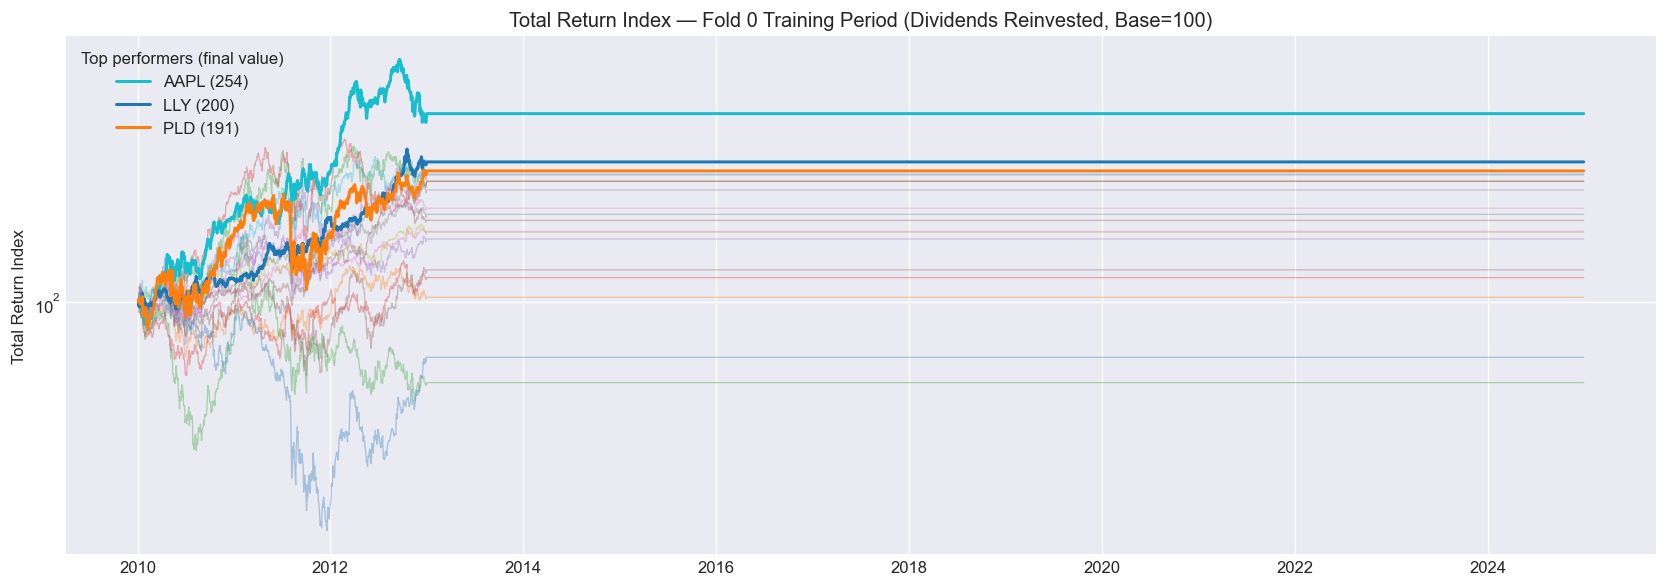

In [10]:
fold0 = pipeline.get_fold(0)
tri = fold0.train_total_returns

fig, ax = plt.subplots(figsize=(14, 5))
for col in tri.columns:
    ax.plot(tri.index, tri[col], alpha=0.35, linewidth=0.8)

# Highlight top performers
final_vals = tri.iloc[-1].sort_values(ascending=False)
for ticker in final_vals.head(3).index:
    ax.plot(tri.index, tri[ticker], linewidth=1.8, label=f'{ticker} ({final_vals[ticker]:.0f})')

ax.set_title('Total Return Index — Fold 0 Training Period (Dividends Reinvested, Base=100)')
ax.set_ylabel('Total Return Index')
ax.set_yscale('log')
ax.legend(title='Top performers (final value)')
plt.tight_layout()
plt.show()

## Next Steps

With the `data` module complete, the next modules to implement are:

1. **`forecasting/`** — GARCH(1,1) volatility, HMM regime detection, Fama-French factor exposures
2. **`agents/`** — LangGraph multi-agent LLM system (Macro, Sector, Company, Orchestrator)
3. **`tax/`** — FIFO lot tracker and tax cost calculator
4. **`rl/`** — Gymnasium environment with differential Sharpe reward + PPO agent
5. **`backtest/`** — Walk-forward backtesting engine and performance metrics